<a href="https://colab.research.google.com/github/Dnyamwamu/neural_nets/blob/main/Notebooks/Chap10/10_5_Convolution_For_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 10.5: Convolution for MNIST**

This notebook builds a proper network for 2D convolution.  It works with the MNIST dataset (figure 15.15a), which was the original classic dataset for classifying images.  The network will take a 28x28 grayscale image and classify it into one of 10 classes representing a digit.

The code is adapted from https://nextjournal.com/gkoehler/pytorch-mnist

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

If you are using Google Colab, you can change your runtime to an instance with GPU support to speed up training, e.g. a T4 GPU. If you do this, the cell below should output ``device(type='cuda')``

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.


In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import random
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [2]:
# Run this once to load the train and test data straight into a dataloader class
# that will provide the batches

# (It may complain that some files are missing because the files seem to have been
# reorganized on the underlying website, but it still seems to work). If everything is working
# properly, then the whole notebook should run to the end without further problems
# even before you make changes.
batch_size_train = 64
batch_size_test = 1000

# TODO Change this directory to point towards an existing directory (No change needed if using Google Colab)
myDir = '/files/'

train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST(myDir, train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST(myDir, train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_test, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.28MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 165kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]


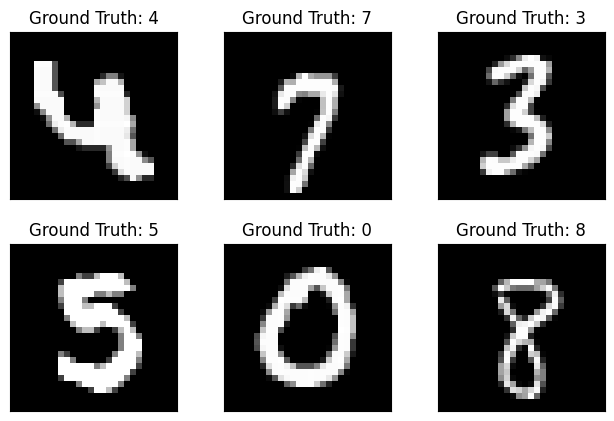

In [3]:
# Let's draw some of the training data
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
plt.show()

Define the network.  This is a more typical way to define a network than the sequential structure.  We define a class for the network, and define the parameters in the constructor.  Then we use a function called forward to actually run the network.  It's easy to see how you might use residual connections in this format.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # 1. Convolution: 1 input channel, 10 output channels, kernel size 5, stride 1, valid padding
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        # 2. Max pooling 2x2
        self.pool1 = nn.MaxPool2d(2,2)
        # 4. Convolution: 10 input channels, 20 output channels, kernel size 5, stride 1, valid padding
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        # 5. Dropout
        self.drop2 = nn.Dropout2d()
        # 6. Max pooling 2x2
        self.pool2 = nn.MaxPool2d(2,2)
        # 8. Flatten will be applied in forward
        # 9. Fully connected layer: input depends on output size after convolutions
        self.fc1 = nn.Linear(20 * 4 * 4, 50)  # compute dimensions dynamically if needed
        # 11. Fully connected layer mapping 50 -> 10
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        # Convolution -> Pool -> ReLU
        x = self.conv1(x)
        x = self.pool1(x)
        x = F.relu(x)

        # Convolution -> Dropout -> Pool -> ReLU
        x = self.conv2(x)
        x = self.drop2(x)
        x = self.pool2(x)
        x = F.relu(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected -> ReLU
        x = self.fc1(x)
        x = F.relu(x)

        # Fully connected -> Softmax
        x = self.fc2(x)
        x = F.log_softmax(x, dim=1)  # apply along the class dimension

        return x

In [5]:
# He initialization of weights
def weights_init(layer_in):
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight)
    layer_in.bias.data.fill_(0.0)

In [6]:
# Create network
model = Net().to(device)
# Initialize model weights
model.apply(weights_init)
# Define optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

In [7]:
# Main training routine
def train(epoch):
  model.train()
  # Get each
  for batch_idx, (data, target) in enumerate(train_loader):
    data = data.to(device)
    target = target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()
    # Store results
    if batch_idx % 10 == 0:
      print('Train Epoch: {} [{}/{}]\tLoss: {:.6f}'.format(
        epoch, batch_idx * len(data), len(train_loader.dataset), loss.item()))

In [8]:
# Run on test data
def test():
  model.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      data = data.to(device)
      target = target.to(device)
      output = model(data)
      test_loss += F.nll_loss(output, target, size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  test_loss /= len(test_loader.dataset)
  print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    test_loss, correct, len(test_loader.dataset),
    100. * correct / len(test_loader.dataset)))

In [9]:
# Get initial performance
test()
# Train for three epochs
n_epochs = 3
for epoch in range(1, n_epochs + 1):
  train(epoch)
  test()

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3178: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Avg. loss: 2.4387, Accuracy: 1583/10000 (16%)

Train Epoch: 1 [0/60000]	Loss: 2.529928
Train Epoch: 1 [640/60000]	Loss: 2.267562
Train Epoch: 1 [1280/60000]	Loss: 1.939839
Train Epoch: 1 [1920/60000]	Loss: 1.954261
Train Epoch: 1 [2560/60000]	Loss: 1.637282
Train Epoch: 1 [3200/60000]	Loss: 1.312186
Train Epoch: 1 [3840/60000]	Loss: 1.384670
Train Epoch: 1 [4480/60000]	Loss: 1.099225
Train Epoch: 1 [5120/60000]	Loss: 1.194332
Train Epoch: 1 [5760/60000]	Loss: 0.969522
Train Epoch: 1 [6400/60000]	Loss: 0.920978
Train Epoch: 1 [7040/60000]	Loss: 0.825862
Train Epoch: 1 [7680/60000]	Loss: 0.965779
Train Epoch: 1 [8320/60000]	Loss: 0.656687
Train Epoch: 1 [8960/60000]	Loss: 0.614244
Train Epoch: 1 [9600/60000]	Loss: 0.780896
Train Epoch: 1 [10240/60000]	Loss: 0.542719
Train Epoch: 1 [10880/60000]	Loss: 0.631450
Train Epoch: 1 [11520/60000]	Loss: 0.708705
Train Epoch: 1 [12160/60000]	Loss: 0.653252
Train Epoch: 1 [12800/60000]	Loss: 0.685832
Train Epoch: 1 [13440/60000]	Loss: 0.5

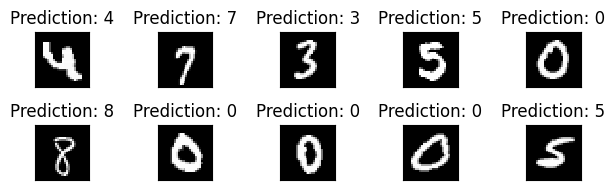

In [10]:
# Run network on data we got before and show predictions
output = model(example_data)

fig = plt.figure()
for i in range(10):
  plt.subplot(5,5,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Prediction: {}".format(
    output.data.max(1, keepdim=True)[1][i].item()))
  plt.xticks([])
  plt.yticks([])
plt.show()